# EDA and Preprocessing

## EDA
Data Visualisation to understand the dataset

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('Datasets/Medical_appointment_data.csv')
print('Shape:', df.shape)
df.head()

Shape: (109593, 26)


,specialty,appointment_time,gender,no_show,disability,place,appointment_shift,age,under_12_years_old,over_60_years_old,...,storm_day_before,rain_intensity,heat_intensity,appointment_date_continuous,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received
0,psychotherapy,17,F,yes,intellectual,Lake Marvinville,afternoon,9.0,1,0,...,1,no_rain,warm,2020-01-01,0,0,0,0,0,0
1,NaN,7,M,no,intellectual,ITAPEMA,morning,11.0,1,0,...,1,no_rain,cold,2020-01-01,0,0,0,0,0,0
2,speech therapy,16,M,no,intellectual,ITAJAÍ,afternoon,8.0,1,0,...,1,no_rain,warm,2020-01-01,0,0,0,0,0,0
3,speech therapy,14,M,yes,intellectual,Sarahside,afternoon,9.0,1,0,...,1,moderate,mild,2020-01-01,0,0,0,0,0,1
4,physiotherapy,8,M,no,motor,ITAJAÍ,morning,NaN,0,0,...,1,no_rain,mild,2020-01-01,0,0,0,0,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109593 entries, 0 to 109592
Data columns (total 26 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   specialty                    89466 non-null   object 
 1   appointment_time             109593 non-null  int64  
 2   gender                       109593 non-null  object 
 3   no_show                      109593 non-null  object 
 4   disability                   92992 non-null   object 
 5   place                        98054 non-null   object 
 6   appointment_shift            109593 non-null  object 
 7   age                          86633 non-null   float64
 8   under_12_years_old           109593 non-null  int64  
 9   over_60_years_old            109593 non-null  int64  
 10  patient_needs_companion      109593 non-null  int64  
 11  average_temp_day             107382 non-null  float64
 12  average_rain_day             107348 non-null  float64
 13 

No-show distribution:
no_show
no     74761
yes    34832
Name: count, dtype: int64

No-show rate: 31.78 %


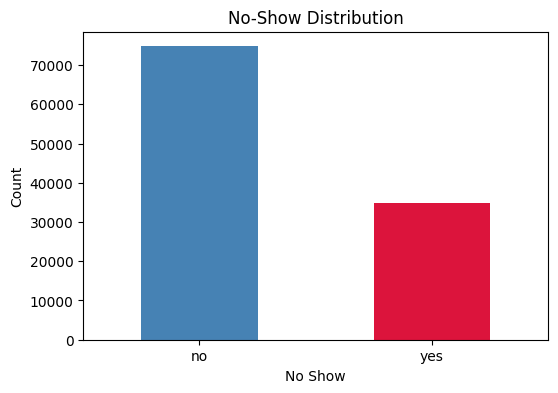

In [29]:
# this is for the no show distribution

import matplotlib.pyplot as plt

print('No-show distribution:')
print(df['no_show'].value_counts())
print()
print('No-show rate:', round(df['no_show'].value_counts(normalize=True)['yes'] * 100, 2), '%')

plt.figure(figsize=(6, 4))
df['no_show'].value_counts().plot(kind='bar', color=['steelblue', 'crimson'])
plt.title('No-Show Distribution')
plt.xlabel('No Show')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

Specialty distribution:
specialty
psychotherapy           28645
speech therapy          22322
physiotherapy           21004
occupational therapy    11319
pedagogo                 3536
enf                      1681
assist                    635
sem especialidade         324
Name: count, dtype: int64


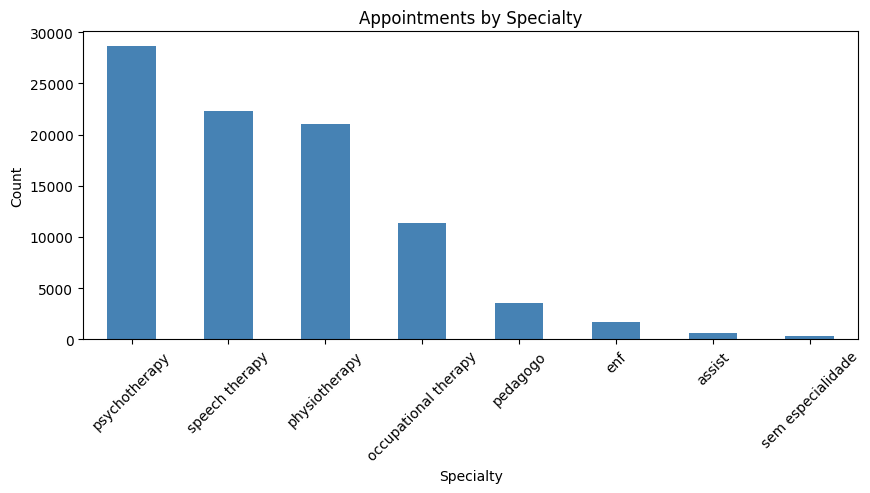

In [30]:
# this is for the specialty distribution

print('Specialty distribution:')
print(df['specialty'].value_counts())

plt.figure(figsize=(10, 4))
df['specialty'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Appointments by Specialty')
plt.xlabel('Specialty')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

No-show rate by specialty:
specialty
sem especialidade       52.777778
physiotherapy           34.364883
psychotherapy           32.337232
speech therapy          27.927605
assist                  26.929134
occupational therapy    23.862532
enf                     19.750149
pedagogo                15.978507
Name: no_show, dtype: float64


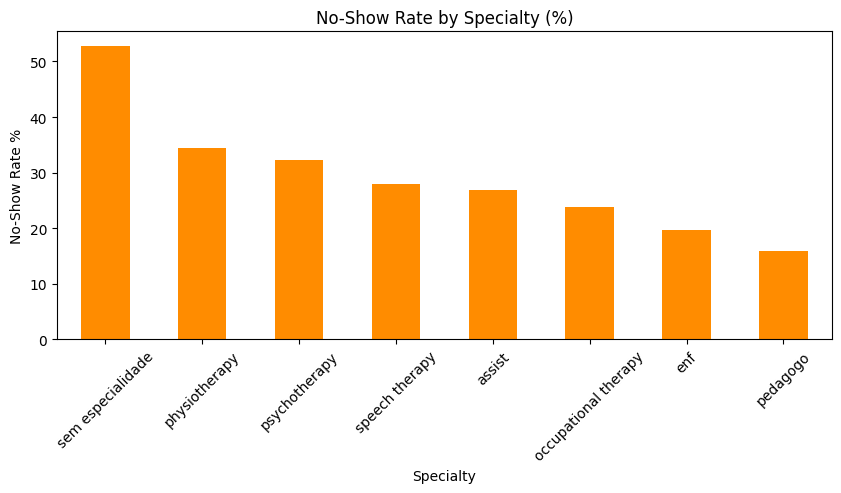

In [31]:
# this is for no show by specialty

spec_noshow = df.groupby('specialty')['no_show'].apply(lambda x: (x == 'yes').mean() * 100)
print('No-show rate by specialty:')
print(spec_noshow.sort_values(ascending=False))

plt.figure(figsize=(10, 4))
spec_noshow.sort_values(ascending=False).plot(kind='bar', color='darkorange')
plt.title('No-Show Rate by Specialty (%)')
plt.xlabel('Specialty')
plt.ylabel('No-Show Rate %')
plt.xticks(rotation=45)
plt.show()

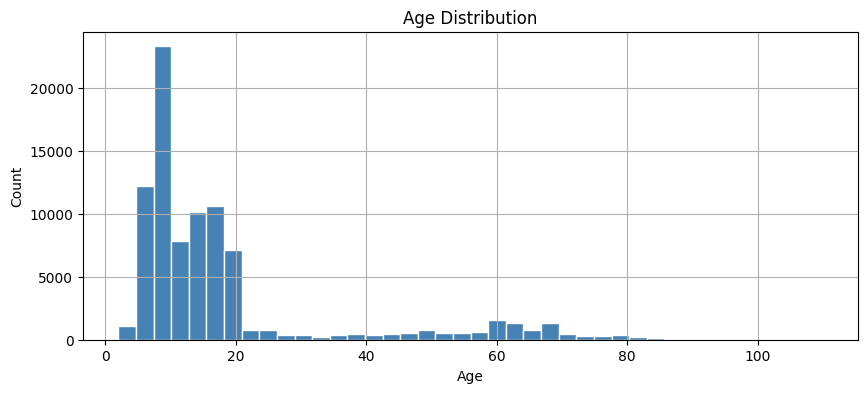

Age stats:
count    86633.000000
mean        18.632138
std         17.666999
min          2.000000
25%          8.000000
50%         12.000000
75%         18.000000
max        110.000000
Name: age, dtype: float64


In [32]:
# this is for age distribution

plt.figure(figsize=(10, 4))
df['age'].dropna().hist(bins=40, color='steelblue', edgecolor='white')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()
print('Age stats:')
print(df['age'].describe())

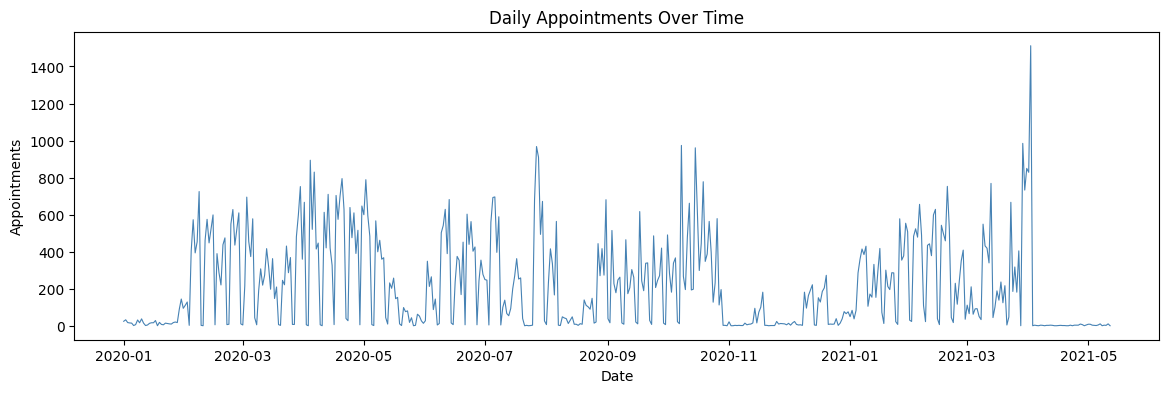

In [33]:
# this is for appointments over time

df['appointment_date_continuous'] = pd.to_datetime(df['appointment_date_continuous'])
daily_counts = df.groupby('appointment_date_continuous').size()

plt.figure(figsize=(14, 4))
plt.plot(daily_counts.index, daily_counts.values, linewidth=0.8, color='steelblue')
plt.title('Daily Appointments Over Time')
plt.xlabel('Date')
plt.ylabel('Appointments')
plt.show()

## Preprocessing

In [35]:
df = pd.read_csv('Datasets/Medical_appointment_data.csv')
df['appointment_date_continuous'] = pd.to_datetime(df['appointment_date_continuous'])

df['no_show'] = (df['no_show'] == 'yes').astype(int)
# to encode target

df['gender_M'] = (df['gender'] == 'M').astype(int)
df['gender_I'] = (~df['gender'].isin(['M', 'F'])).astype(int)
df = df.drop(columns=['gender'])
# to encode gender

df['appointment_shift'] = df['appointment_shift'].map({'morning': 0, 'afternoon': 1}).fillna(0).astype(int)
# to encode appointment shift

df['age_missing'] = df['age'].isnull().astype(int)
df['age'] = df['age'].fillna(df['age'].median())
# to handle age

df['disability_intellectual'] = (df['disability'] == 'intellectual').astype(int)
df['disability_motor'] = (df['disability'] == 'motor').astype(int)
df = df.drop(columns=['disability'])
# to handle disability

df['rain_no_rain'] = (df['rain_intensity'] == 'no_rain').astype(int)
df['rain_weak'] = (df['rain_intensity'] == 'weak').astype(int)
df['rain_moderate'] = (df['rain_intensity'] == 'moderate').astype(int)
df = df.drop(columns=['rain_intensity'])
# to encode rain intensity

df['heat_mild'] = (df['heat_intensity'] == 'mild').astype(int)
df['heat_warm'] = (df['heat_intensity'] == 'warm').astype(int)
df['heat_heavy_warm'] = (df['heat_intensity'] == 'heavy_warm').astype(int)
df['heat_heavy_cold'] = (df['heat_intensity'] == 'heavy_cold').astype(int)
df = df.drop(columns=['heat_intensity'])
# to encode heat intensity

for col in ['average_temp_day', 'average_rain_day', 'max_temp_day', 'max_rain_day']:
    df[col] = df[col].fillna(df[col].median())
# to fill weather missing with median

df['specialty'] = df['specialty'].fillna('Unknown')
df['place'] = df['place'].fillna('Unknown')
# to fill specialty and place missing

print('Final shape:', df.shape)
print('Columns:', df.columns.tolist())
print('Missing values remaining:', df.isnull().sum().sum())

df.to_csv('Datasets/cleaned_dataset.csv', index=False)
print('Cleaned dataset saved!')

Final shape: (109593, 34)
Columns: ['specialty', 'appointment_time', 'no_show', 'place', 'appointment_shift', 'age', 'under_12_years_old', 'over_60_years_old', 'patient_needs_companion', 'average_temp_day', 'average_rain_day', 'max_temp_day', 'max_rain_day', 'rainy_day_before', 'storm_day_before', 'appointment_date_continuous', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'Scholarship', 'SMS_received', 'gender_M', 'gender_I', 'age_missing', 'disability_intellectual', 'disability_motor', 'rain_no_rain', 'rain_weak', 'rain_moderate', 'heat_mild', 'heat_warm', 'heat_heavy_warm', 'heat_heavy_cold']
Missing values remaining: 0
Cleaned dataset saved!


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109593 entries, 0 to 109592
Data columns (total 34 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   specialty                    109593 non-null  object        
 1   appointment_time             109593 non-null  int64         
 2   no_show                      109593 non-null  int64         
 3   place                        109593 non-null  object        
 4   appointment_shift            109593 non-null  int64         
 5   age                          109593 non-null  float64       
 6   under_12_years_old           109593 non-null  int64         
 7   over_60_years_old            109593 non-null  int64         
 8   patient_needs_companion      109593 non-null  int64         
 9   average_temp_day             109593 non-null  float64       
 10  average_rain_day             109593 non-null  float64       
 11  max_temp_day              